# HR Analytics Dashboard – Employee Attrition Analysis

### Business Problem

Employee attrition is a major challenge for organizations because it increases recruitment costs, affects productivity, and reduces workforce stability.

The objective of this project is to analyze employee attrition patterns using the IBM HR Analytics dataset and identify high-risk employee groups through Python, SQL, and Power BI.

## 1. Import Required Libraries

The following libraries are used for data manipulation, visualization, and analysis.

In [19]:
# Import required libraries for data analysis and visualization

import pandas as pd

## 2. Load Dataset

The IBM HR Analytics Employee Attrition dataset is loaded into a Pandas DataFrame for further analysis.

In [20]:
# Load the IBM HR Analytics dataset into a Pandas DataFrame
df = pd.read_csv(r"C:\Users\Shakshi\OneDrive\Desktop\HR project\IBM_HR_Attrition_Dataset.csv")

df.head()

,EmployeeNumber,Age,Gender,MaritalStatus,Education,Department,JobRole,JobLevel,BusinessTravel,OverTime,...,PerformanceRating,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,TrainingTimesLastYear,SalarySlab,AgeBand,TenureBand,Attrition
0,1,47,Female,Married,1,Research & Development,Manager,2,Travel_Rarely,No,...,3,1,4,2,3,3,35K-60K,46+,0-3 yrs,No
1,2,43,Male,Married,2,Human Resources,Human Resources Representative,2,Non-Travel,No,...,4,4,3,3,3,2,<=35K,36-45,4-7 yrs,No
2,3,40,Female,Single,2,Research & Development,Research Scientist,1,Travel_Rarely,No,...,3,4,3,1,3,3,<=35K,36-45,0-3 yrs,Yes
3,4,46,Male,Single,4,Research & Development,Healthcare Representative,2,Travel_Rarely,No,...,3,4,4,3,3,2,<=35K,46+,4-7 yrs,No
4,5,36,Male,Single,2,Sales,Sales Representative,1,Travel_Rarely,No,...,3,2,4,2,1,4,<=35K,36-45,4-7 yrs,No


## 3. Dataset Overview

This section verifies the number of rows and columns available in the dataset.

In [21]:
# Check the number of rows and columns in the dataset

df.shape

(1470, 28)

## 4. Dataset Information

Checking data types, non-null values, and memory usage to understand the dataset structure.

In [22]:
# Display dataset structure, data types, and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeNumber            1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Gender                    1470 non-null   object 
 3   MaritalStatus             1470 non-null   object 
 4   Education                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   JobRole                   1470 non-null   object 
 7   JobLevel                  1470 non-null   int64  
 8   BusinessTravel            1470 non-null   object 
 9   OverTime                  1470 non-null   object 
 10  MonthlyIncome             1470 non-null   int64  
 11  PercentSalaryHike         1470 non-null   float64
 12  StockOptionLevel          1470 non-null   int64  
 13  TotalWorkingYears         1470 non-null   int64  
 14  YearsAtC

## 5. Data Validation

The dataset was checked for missing values to ensure data quality before performing the analysis. No missing values were found, indicating that the dataset is complete and ready for analysis.

In [23]:
# Check for missing values in each column

df.isnull().sum()

EmployeeNumber              0
Age                         0
Gender                      0
MaritalStatus               0
Education                   0
Department                  0
JobRole                     0
JobLevel                    0
BusinessTravel              0
OverTime                    0
MonthlyIncome               0
PercentSalaryHike           0
StockOptionLevel            0
TotalWorkingYears           0
YearsAtCompany              0
YearsInCurrentRole          0
YearsWithCurrManager        0
YearsSinceLastPromotion     0
PerformanceRating           0
JobSatisfaction             0
EnvironmentSatisfaction     0
RelationshipSatisfaction    0
WorkLifeBalance             0
TrainingTimesLastYear       0
SalarySlab                  0
AgeBand                     0
TenureBand                  0
Attrition                   0
dtype: int64

In [24]:
# Calculate overall employee attrition distribution

df['Attrition'].value_counts()

# Insight:
# The overall employee attrition rate is 20.5%, indicating that
# approximately one out of every five employees has left the organization.

Attrition
No     1169
Yes     301
Name: count, dtype: int64

In [25]:
round(df['Attrition'].value_counts(normalize=True)*100,2)

Attrition
No     79.52
Yes    20.48
Name: proportion, dtype: float64

## 6. Department-wise Attrition Analysis

This section analyzes employee attrition across different departments to identify which department experiences the highest employee turnover.

In [26]:
# Analyze attrition rate across different departments

round(
    pd.crosstab(
        df['Department'],
        df['Attrition'],
        normalize='index'
    ) * 100,
    2
)

# Insight:
# Human Resources records the highest attrition rate (26.81%),
# followed by Sales (21.69%) and Research & Development (18.83%).


Attrition,No,Yes
Department,,
Human Resources,73.19,26.81
Research & Development,81.17,18.83
Sales,78.31,21.69


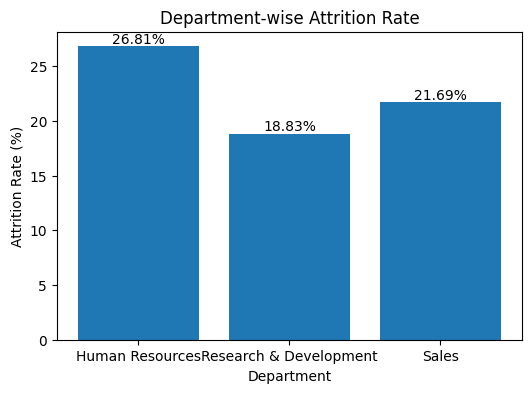

In [31]:
import matplotlib.pyplot as plt

dept = round(pd.crosstab(df['Department'], df['Attrition'], normalize='index')*100,2)

plt.figure(figsize=(6,4))
plt.bar(dept.index, dept['Yes'])
plt.title("Department-wise Attrition Rate")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

for i, value in enumerate(dept['Yes']):
    plt.text(i, value+0.3, f"{value:.2f}%", ha='center')

plt.show()


### Business Insight

- Human Resources records the highest attrition rate (26.81%).
- Sales follows with 21.69%.
- Research & Development has the lowest attrition among the three departments (18.83%).

## 7. Salary Slab Analysis

This analysis compares employee attrition across different salary groups to understand the relationship between salary and employee turnover.

In [27]:
# Analyze attrition based on employee salary slabs

round(
    pd.crosstab(
        df['SalarySlab'],
        df['Attrition'],
        normalize='index'
    ) * 100,
    2
)

# Insight:
# Employees earning ≤ ₹35K have the highest attrition rate (27.26%),
# suggesting that lower salary is associated with higher employee turnover.

Attrition,No,Yes
SalarySlab,,
35K-60K,87.60,12.40
<=35K,72.74,27.26
>60K,90.78,9.22


## 8. Age Band Analysis

This section analyzes employee attrition across different age groups to identify which age category experiences the highest employee turnover.

In [28]:
# Analyze employee attrition across different age groups

round(
    pd.crosstab(
        df['AgeBand'],
        df['Attrition'],
        normalize='index'
    ) * 100,
    2
)

# Insight:
# Employees aged 18–25 show the highest attrition rate (25.15%),
# indicating that younger employees are more likely to leave the organization.

Attrition,No,Yes
AgeBand,,
18-25,74.85,25.15
26-35,79.37,20.63
36-45,80.57,19.43
46+,80.69,19.31


## 9. Employee Tenure Analysis

This section evaluates employee attrition based on tenure to identify whether newer or experienced employees are more likely to leave.

In [29]:
# Analyze attrition based on employee tenure

round(
    pd.crosstab(
        df['TenureBand'],
        df['Attrition'],
        normalize='index'
    ) * 100,
    2
)

# Insight:
# Employees with 0–3 years of tenure have the highest attrition rate (22.34%),
# highlighting higher turnover during the early years of employment.

Attrition,No,Yes
TenureBand,,
0-3 yrs,77.66,22.34
4-7 yrs,79.67,20.33
8+ yrs,83.90,16.10


## 10. High-Risk Employee Segment

This analysis identifies the highest-risk employee segment by combining employee job role, salary slab, and tenure. The objective is to determine which group has the highest probability of leaving the organization.

In [30]:
# Identify the highest-risk employee segment using job role, salary, and tenure

risk = df[
    (df['JobRole'] == 'Sales Executive') &
    (df['TenureBand'] == '0-3 yrs') &
    (df['SalarySlab'] == '<=35K')
]

round(risk['Attrition'].value_counts(normalize=True) * 100, 2)

# Insight:
# Sales Executives earning ≤ ₹35K with 0–3 years of tenure
# represent the highest-risk employee segment with a 31.1% attrition rate.

Attrition
No     68.89
Yes    31.11
Name: proportion, dtype: float64

## 11. Key Business Insights

- Overall Attrition Rate: 20.5%
- Human Resources has the highest attrition rate (26.81%).
- Employees earning ≤ ₹35K show the highest attrition (27.26%).
- Employees aged 18–25 have the highest attrition (25.15%).
- Employees with 0–3 years tenure have the highest attrition (22.34%).
- Sales Executives earning ≤ ₹35K with 0–3 years tenure represent the highest-risk employee segment (31.1%).

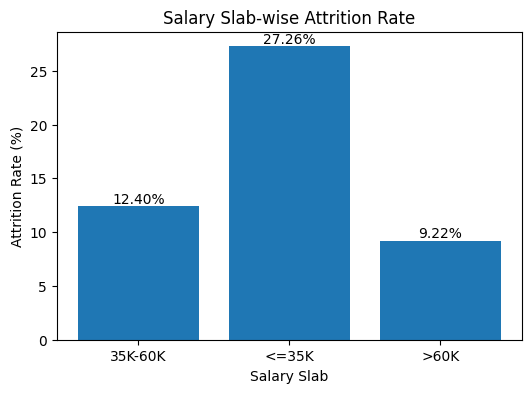

In [32]:
salary = round(pd.crosstab(df['SalarySlab'], df['Attrition'], normalize='index')*100,2)

plt.figure(figsize=(6,4))
plt.bar(salary.index, salary['Yes'])
plt.title("Salary Slab-wise Attrition Rate")
plt.xlabel("Salary Slab")
plt.ylabel("Attrition Rate (%)")

for i, value in enumerate(salary['Yes']):
    plt.text(i, value+0.3, f"{value:.2f}%", ha='center')

plt.show()

### Business Insight

- Employees earning ≤ ₹35K have the highest attrition rate (27.26%).
- Attrition decreases as salary increases.
- Higher salary appears to improve employee retention.

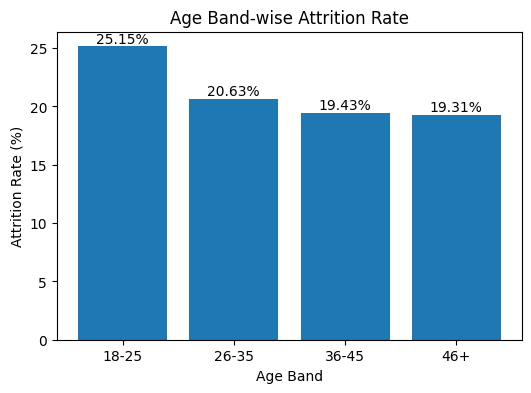

In [33]:
age = round(pd.crosstab(df['AgeBand'], df['Attrition'], normalize='index')*100,2)

plt.figure(figsize=(6,4))
plt.bar(age.index, age['Yes'])
plt.title("Age Band-wise Attrition Rate")
plt.xlabel("Age Band")
plt.ylabel("Attrition Rate (%)")

for i, value in enumerate(age['Yes']):
    plt.text(i, value+0.3, f"{value:.2f}%", ha='center')

plt.show()

### Business Insight

- Employees aged 18–25 have the highest attrition rate (25.15%).
- Attrition gradually decreases with increasing age.

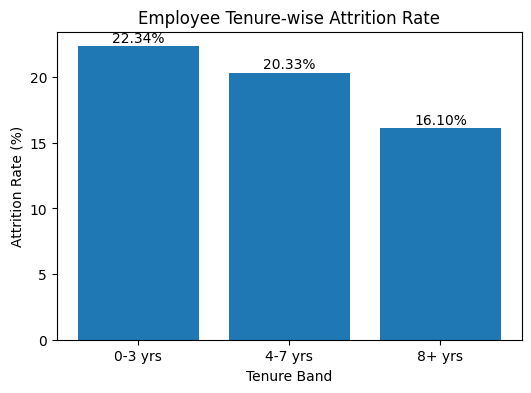

In [34]:
tenure = round(pd.crosstab(df['TenureBand'], df['Attrition'], normalize='index')*100,2)

plt.figure(figsize=(6,4))
plt.bar(tenure.index, tenure['Yes'])
plt.title("Employee Tenure-wise Attrition Rate")
plt.xlabel("Tenure Band")
plt.ylabel("Attrition Rate (%)")

for i, value in enumerate(tenure['Yes']):
    plt.text(i, value+0.3, f"{value:.2f}%", ha='center')

plt.show()

### Business Insight

- Employees with 0–3 years of tenure have the highest attrition (22.34%).
- Attrition decreases as employee tenure increases.

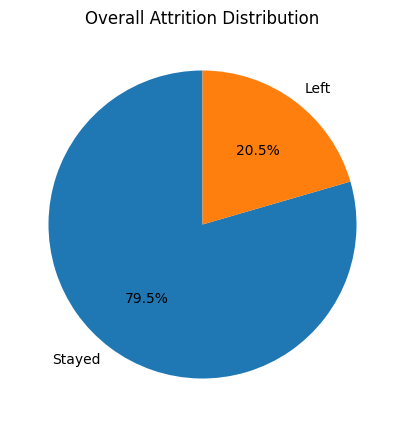

In [35]:
labels = ['Stayed','Left']
sizes = [79.5,20.5]

plt.figure(figsize=(5,5))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Overall Attrition Distribution")
plt.show()

### Business Insight

- Overall attrition rate is 20.5%.
- Approximately one out of every five employees has left the organization.
- Sales Executives earning ≤ ₹35K with 0–3 years of tenure represent the highest-risk employee segment (31.1% attrition).

# Conclusion

The analysis shows that salary, age, department, and employee tenure significantly influence attrition. The insights were visualized through an interactive Power BI dashboard to support HR decision-making and employee retention strategies.

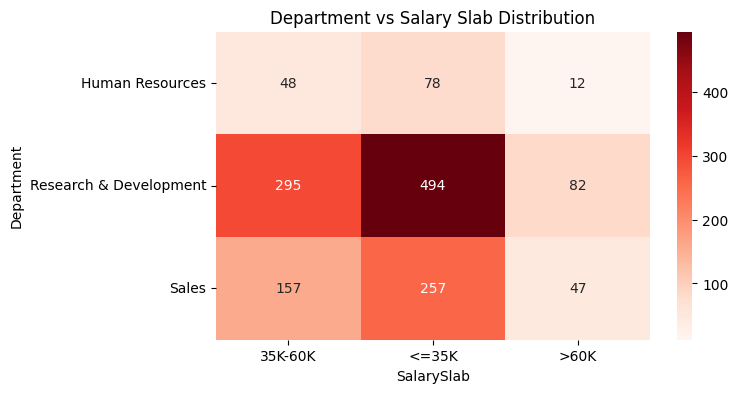

In [36]:
import seaborn as sns

heat = pd.crosstab(df['Department'], df['SalarySlab'])

plt.figure(figsize=(7,4))
sns.heatmap(heat, annot=True, fmt='d', cmap='Reds')

plt.title("Department vs Salary Slab Distribution")
plt.show()

### Final Observation

The analysis shows that employee attrition is primarily influenced by salary, age, department, and tenure. These insights were used to design the interactive Power BI dashboard for HR decision-making.